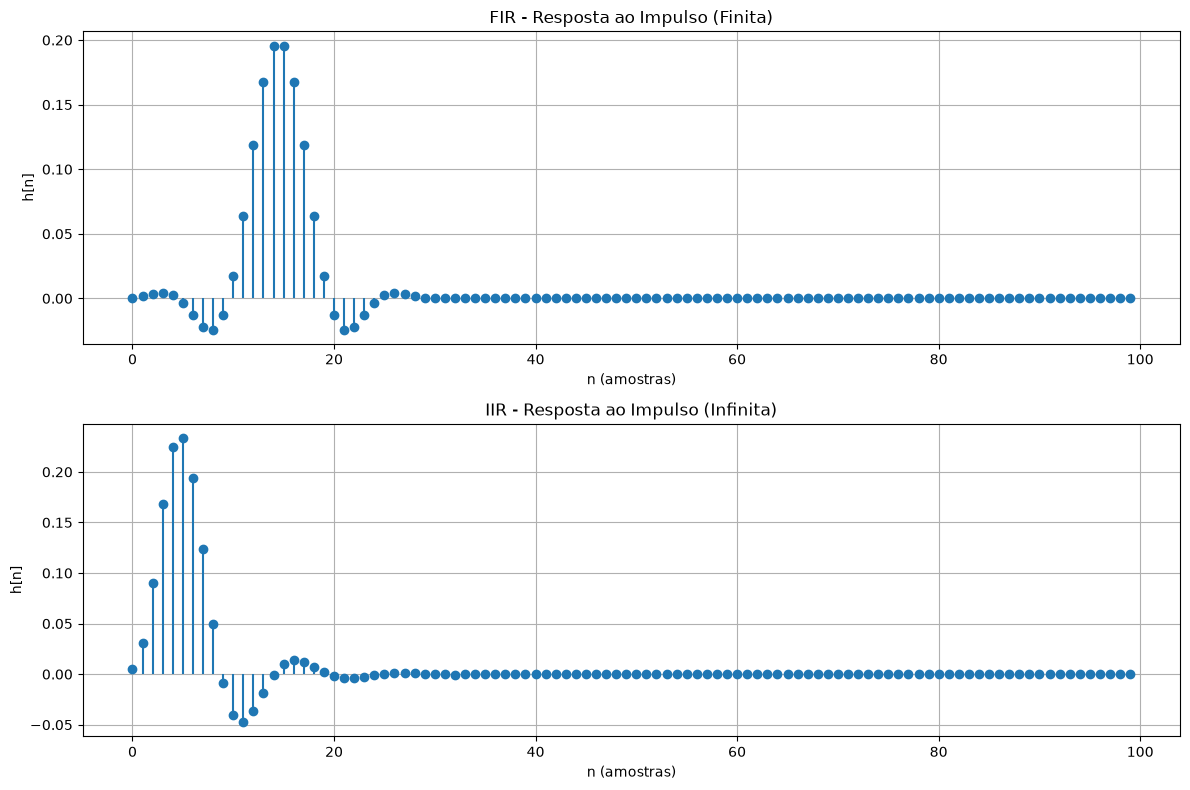

Resposta ao impulso FIR - Duração: 30 amostras (finita)
Resposta ao impulso IIR - Últimas amostras: [-1.43865181e-10 -1.67687027e-10 -1.30470966e-10 -6.62387638e-11
 -4.94163135e-12]
A resposta IIR tende assintoticamente a zero, nunca se anulando completamente
A resposta FIR se anula após um número finito de amostras

Energia da resposta ao impulso (FIR): 0.1724
Energia da resposta ao impulso (IIR): 0.2038


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
fs = 1000
fc = 100  # Frequência de corte (Hz)

# Projeto dos filtros
b_fir = signal.firwin(30, fc, fs=fs, window='hamming')
b_iir, a_iir = signal.butter(4, fc, fs=fs, btype='low')

# Resposta ao impulso
impulso = np.zeros(100)
impulso[0] = 1

h_fir = signal.lfilter(b_fir, [1.0], impulso)
h_iir = signal.lfilter(b_iir, a_iir, impulso)

# Gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# FIR
axes[0].stem(range(len(h_fir)), h_fir, basefmt=' ')
axes[0].set_xlabel('n (amostras)')
axes[0].set_ylabel('h[n]')
axes[0].set_title('FIR - Resposta ao Impulso (Finita)')
axes[0].grid()

# IIR
axes[1].stem(range(len(h_iir)), h_iir, basefmt=' ')
axes[1].set_xlabel('n (amostras)')
axes[1].set_ylabel('h[n]')
axes[1].set_title('IIR - Resposta ao Impulso (Infinita)')
axes[1].grid()

plt.tight_layout()
plt.show()

# Análise da duração
print(f"Resposta ao impulso FIR - Duração: {len(h_fir[np.abs(h_fir) > 1e-6])} amostras (finita)")
print(f"Resposta ao impulso IIR - Últimas amostras: {h_iir[-5:]}")
print("A resposta IIR tende assintoticamente a zero, nunca se anulando completamente")
print("A resposta FIR se anula após um número finito de amostras")

# Energia da resposta ao impulso
energia_fir = np.sum(h_fir**2)
energia_iir = np.sum(h_iir**2)
print(f"\nEnergia da resposta ao impulso (FIR): {energia_fir:.4f}")
print(f"Energia da resposta ao impulso (IIR): {energia_iir:.4f}")

# Discussão dos Resultados
A resposta ao impulso do filtro FIR tem duração finita, igual ao número de coeficientes do filtro. Isso ocorre porque não há realimentação: após a entrada impulsiva passar por todos os taps, a saída se torna zero. Já a resposta ao impulso do filtro IIR tem duração teoricamente infinita devido à realimentação: cada amostra de saída depende das saídas anteriores, perpetuando o efeito do impulso. Na prática, a resposta IIR decai exponencialmente, podendo ser truncada quando os valores se tornam desprezíveis.